In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\nirma\bhuvana\insurance.csv")

In [7]:
#Load Dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
#Understand Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
#Handling Missing Values
df['age'] = df['age'].fillna(df['age'].median())
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

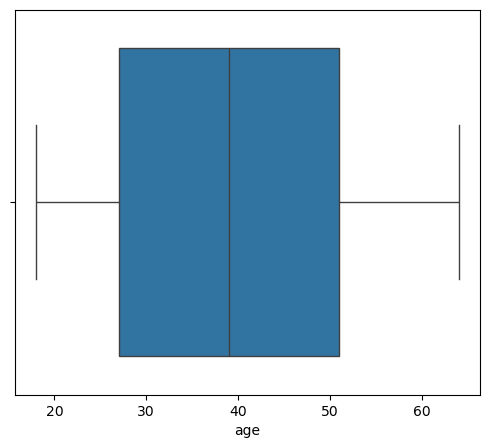

In [12]:
#Outlier Detection
plt.figure(figsize=(6,5))
sns.boxplot(x=df['age'])
plt.show()

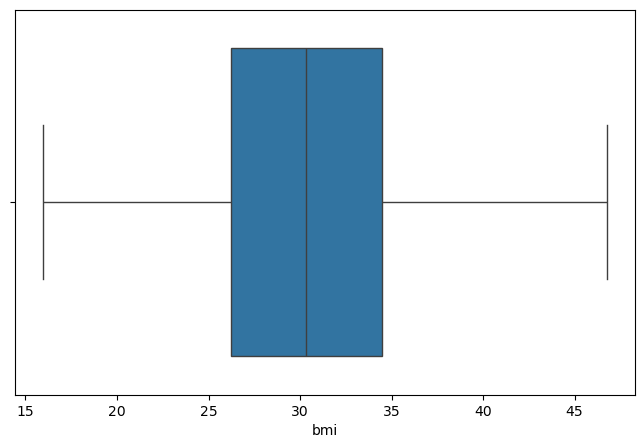

In [13]:
#Outlier Treatment Using IQR
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df = df[(df['bmi'] >= lower_limit) & (df['bmi'] <= upper_limit)]
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bmi'])
plt.show()

In [14]:
#Encoding Categorical Variables
df.select_dtypes(include='object').columns
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [15]:
#One Hot Encoding
df= pd.get_dummies(df, columns=['bmi'], drop_first=True)
df

,age,sex,children,smoker,region,charges,bmi_16.815,bmi_17.195,bmi_17.29,bmi_17.385,...,bmi_44.88,bmi_45.32,bmi_45.43,bmi_45.54,bmi_45.9,bmi_46.09,bmi_46.2,bmi_46.53,bmi_46.7,bmi_46.75
0,19,female,0,yes,southwest,16884.92400,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,18,male,1,no,southeast,1725.55230,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,28,male,3,no,southeast,4449.46200,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,33,male,0,no,northwest,21984.47061,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,32,male,0,no,northwest,3866.85520,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,3,no,northwest,10600.54830,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1334,18,female,0,no,northeast,2205.98080,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1335,18,female,0,no,southeast,1629.83350,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1336,21,female,0,no,southwest,2007.94500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df.head()

,age,sex,children,smoker,region,charges,bmi_16.815,bmi_17.195,bmi_17.29,bmi_17.385,...,bmi_44.88,bmi_45.32,bmi_45.43,bmi_45.54,bmi_45.9,bmi_46.09,bmi_46.2,bmi_46.53,bmi_46.7,bmi_46.75
0,19,0,0,yes,southwest,16884.92400,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,18,1,1,no,southeast,1725.55230,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,28,1,3,no,southeast,4449.46200,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,33,1,0,no,northwest,21984.47061,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,32,1,0,no,northwest,3866.85520,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
#Drop Unnecessary Columns
df.columns

Index(['age', 'sex', 'children', 'smoker', 'region', 'charges', 'bmi_16.815',
       'bmi_17.195', 'bmi_17.29', 'bmi_17.385',
       ...
       'bmi_44.88', 'bmi_45.32', 'bmi_45.43', 'bmi_45.54', 'bmi_45.9',
       'bmi_46.09', 'bmi_46.2', 'bmi_46.53', 'bmi_46.7', 'bmi_46.75'],
      dtype='object', length=544)

In [21]:
#Separate Features and Target
X = df.drop('age', axis=1)
y = df['age']

In [22]:
df

,age,sex,children,smoker,region,charges,bmi_16.815,bmi_17.195,bmi_17.29,bmi_17.385,...,bmi_44.88,bmi_45.32,bmi_45.43,bmi_45.54,bmi_45.9,bmi_46.09,bmi_46.2,bmi_46.53,bmi_46.7,bmi_46.75
0,19,0,0,yes,southwest,16884.92400,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,18,1,1,no,southeast,1725.55230,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,28,1,3,no,southeast,4449.46200,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,33,1,0,no,northwest,21984.47061,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,32,1,0,no,northwest,3866.85520,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,3,no,northwest,10600.54830,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1334,18,0,0,no,northeast,2205.98080,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1335,18,0,0,no,southeast,1629.83350,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1336,21,0,0,no,southwest,2007.94500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [23]:
df.columns

Index(['age', 'sex', 'children', 'smoker', 'region', 'charges', 'bmi_16.815',
       'bmi_17.195', 'bmi_17.29', 'bmi_17.385',
       ...
       'bmi_44.88', 'bmi_45.32', 'bmi_45.43', 'bmi_45.54', 'bmi_45.9',
       'bmi_46.09', 'bmi_46.2', 'bmi_46.53', 'bmi_46.7', 'bmi_46.75'],
      dtype='object', length=544)

In [26]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

In [28]:
df

,age,sex,children,smoker,region,charges,bmi_16.815,bmi_17.195,bmi_17.29,bmi_17.385,...,bmi_44.88,bmi_45.32,bmi_45.43,bmi_45.54,bmi_45.9,bmi_46.09,bmi_46.2,bmi_46.53,bmi_46.7,bmi_46.75
0,19,0,0,yes,southwest,16884.92400,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,18,1,1,no,southeast,1725.55230,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,28,1,3,no,southeast,4449.46200,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,33,1,0,no,northwest,21984.47061,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,32,1,0,no,northwest,3866.85520,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,3,no,northwest,10600.54830,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1334,18,0,0,no,northeast,2205.98080,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1335,18,0,0,no,southeast,1629.83350,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1336,21,0,0,no,southwest,2007.94500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ValueError: could not convert string to float: 'no'

In [ ]:
s